In [1]:
#다운로드 받은 알집 파일을 풀기
import zipfile
import os

# 압축을 풀 파일 이름
zip_file_path = '235713_신용카드 사용자 연체 예측 AI 경진대회_data.zip'

# 압축을 풀 경로 (현재 폴더 내 data 폴더)
extract_path = './data'

# 폴더가 없으면 생성
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# 압축 해제
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"압축 해제 완료: {extract_path}")

압축 해제 완료: ./data


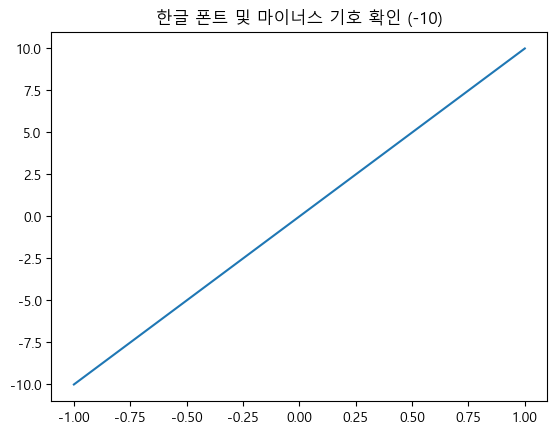

In [33]:
import matplotlib.pyplot as plt
import platform

# 시스템의 OS를 확인하여 적절한 한글 폰트 설정
if platform.system() == 'Windows':
    # 윈도우의 경우 '맑은 고딕'
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    # 맥(Mac)의 경우 'AppleGothic'
    plt.rc('font', family='AppleGothic')
else:
    # 리눅스 등의 경우 (코랩 포함) 'NanumGothic' (설치 필요할 수 있음)
    plt.rc('font', family='NanumGothic')

# 그래프에서 마이너스(-) 기호가 깨지는 문제 해결
plt.rc('axes', unicode_minus=False)

# 설정 확인용 테스트 그래프
plt.figure()
plt.title('한글 폰트 및 마이너스 기호 확인 (-10)')
plt.plot([-1, 0, 1], [-10, 0, 10])
plt.show()

| 변수명 (Column) | 의미 (Description) | 데이터 타입/범주 | 특이사항 (Note) |
| --- | --- | --- | --- |
| **index** | 고유 인덱스 | Integer | 분석 시 제외 대상 |
| **gender** | 성별 | 범주형 (F, M) |  |
| **car** | 차량 소유 여부 | 범주형 (Y, N) |  |
| **reality** | 부동산 소유 여부 | 범주형 (Y, N) |  |
| **child_num** | 자녀 수 | Integer |  |
| **income_total** | 연간 소득 | Float | 스케일링 필요 |
| **income_type** | 소득 분류 | 범주형 (5종) | Commercial associate, Working, State servant, Pensioner, Student |
| **edu_type** | 교육 수준 | 범주형 (5종) | Higher education, Secondary..., Incomplete higher, Lower secondary, Academic degree |
| **family_type** | 결혼 여부 | 범주형 (5종) | Married, Civil marriage, Separated, Single / not married, Widow |
| **house_type** | 생활 방식 | 범주형 (6종) | Municipal apartment, House / apartment, With parents, Co-op..., Rented..., Office... |
| **DAYS_BIRTH** | 출생일 | Integer | 음수 값 (0 기준 역산), 나이 변환 필요 |
| **DAYS_EMPLOYED** | 업무 시작일 | Integer | 음수(근속일), 양수(무직) |
| **FLAG_MOBIL** | 핸드폰 소유 여부 | Binary (0, 1) |  |
| **work_phone** | 업무용 전화 소유 여부 | Binary (0, 1) |  |
| **phone** | 전화 소유 여부 | Binary (0, 1) |  |
| **email** | 이메일 소유 여부 | Binary (0, 1) |  |
| **occyp_type** | 직업 유형 | 범주형 | 결측치 존재 가능성 높음 |
| **family_size** | 가족 규모 | Integer |  |
| **begin_month** | 카드 발급 월 | Integer | 음수 값, 카드 사용 기간 의미 |
| **credit** | 신용도 (Target) | Integer (0, 1, 2) | 낮을수록 높은 신용 (0: 우량, 1: 보통, 2: 낮음) |

In [66]:
# 1. 번역 사전 만들기
income_type_dic = {
    'Commercial associate': '상업 종사자',
    'Working': '근로자',
    'State servant': '공무원',
    'Pensioner': '연금 수급자',
    'Student': '학생'
}

# 2. 실제 데이터에 적용하기 (이 줄이 빠졌습니다!)
train['income_type'] = train['income_type'].map(income_type_dic)
# test['income_type'] = test['income_type'].map(income_type_dic) # test 데이터도 있다면 함께 적용

# 3. 결과 확인
print(train['income_type'].value_counts())

income_type
근로자       13645
상업 종사자     6202
연금 수급자     4449
공무원        2154
학생            7
Name: count, dtype: int64


In [54]:
# 한글 변환을 위한 딕셔너리 생성
house_type_kor = {
    'House / apartment': '자가/아파트',
    'With parents': '부모님 거주',
    'Municipal apartment': '공공임대',
    'Rented apartment': '민간임대',
    'Office apartment': '오피스텔',
    'Co-op apartment': '조합주택'
}

# map 함수를 사용하여 변경 (train, test 둘 다 적용!)
train['house_type'] = train['house_type'].map(house_type_kor)
test['house_type'] = test['house_type'].map(house_type_kor)

# 변경 결과 확인
print(train['house_type'].value_counts())

print(train['house_type'].value_counts())

house_type
자가/아파트    23653
부모님 거주     1257
공공임대        818
민간임대        429
오피스텔        190
조합주택        110
Name: count, dtype: int64
house_type
자가/아파트    23653
부모님 거주     1257
공공임대        818
민간임대        429
오피스텔        190
조합주택        110
Name: count, dtype: int64


In [71]:
# 교육 수준 번역 딕셔너리
edu_type_dic = {
    'Higher education': '대학교 졸업',
    'Secondary / secondary special': '중/고등학교 졸업',
    'Incomplete higher': '대학 중퇴/수료',
    'Lower secondary': '중학교 졸업',
    'Academic degree': '석/박사 학위'
}

# train, test 데이터에 적용
train['edu_type'] = train['edu_type'].map(edu_type_dic)
test['edu_type'] = test['edu_type'].map(edu_type_dic)

# 결과 확인
print(train['edu_type'].value_counts())

edu_type
중/고등학교 졸업    17995
대학교 졸업        7162
대학 중퇴/수료      1020
중학교 졸업         257
석/박사 학위         23
Name: count, dtype: int64


In [72]:
# 결혼 상태 번역 딕셔너리
family_type_dic = {
    'Married': '기혼',
    'Civil marriage': '사실혼',
    'Separated': '별거',
    'Single / not married': '미혼',
    'Widow': '사별'
}

# train, test 데이터에 적용
train['family_type'] = train['family_type'].map(family_type_dic)
test['family_type'] = test['family_type'].map(family_type_dic)

# 결과 확인
print(train['family_type'].value_counts())

family_type
기혼     18196
미혼      3496
사실혼     2123
별거      1539
사별      1103
Name: count, dtype: int64


### 라이블러리 불러오기

In [2]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### 파일 가져오기

In [3]:
# 파일 가져오기
train = pd.read_csv('./data/open/train.csv')
test = pd.read_csv('./data/open/test.csv')
train.head()

,index,gender,car,reality,child_num,income_total,income_type,edu_type,family_type,house_type,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,work_phone,phone,email,occyp_type,family_size,begin_month,credit
0,0,F,N,N,0,202500.0,Commercial associate,Higher education,Married,Municipal apartment,-13899,-4709,1,0,0,0,NaN,2.0,-6.0,1.0
1,1,F,N,Y,1,247500.0,Commercial associate,Secondary / secondary special,Civil marriage,House / apartment,-11380,-1540,1,0,0,1,Laborers,3.0,-5.0,1.0
2,2,M,Y,Y,0,450000.0,Working,Higher education,Married,House / apartment,-19087,-4434,1,0,1,0,Managers,2.0,-22.0,2.0
3,3,F,N,Y,0,202500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-15088,-2092,1,0,1,0,Sales staff,2.0,-37.0,0.0
4,4,F,Y,Y,0,157500.0,State servant,Higher education,Married,House / apartment,-15037,-2105,1,0,0,0,Managers,2.0,-26.0,2.0


### 데이터 분석

In [57]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26457 entries, 0 to 26456
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          26457 non-null  int64  
 1   gender         26457 non-null  object 
 2   car            26457 non-null  object 
 3   reality        26457 non-null  object 
 4   child_num      26457 non-null  int64  
 5   income_total   26457 non-null  float64
 6   income_type    26457 non-null  object 
 7   edu_type       26457 non-null  object 
 8   family_type    26457 non-null  object 
 9   house_type     26457 non-null  object 
 10  DAYS_BIRTH     26457 non-null  int64  
 11  DAYS_EMPLOYED  26457 non-null  int64  
 12  FLAG_MOBIL     26457 non-null  int64  
 13  work_phone     26457 non-null  int64  
 14  phone          26457 non-null  int64  
 15  email          26457 non-null  int64  
 16  occyp_type     18286 non-null  object 
 17  family_size    26457 non-null  float64
 18  begin_

In [5]:
train.isnull().sum()

index               0
gender              0
car                 0
reality             0
child_num           0
income_total        0
income_type         0
edu_type            0
family_type         0
house_type          0
DAYS_BIRTH          0
DAYS_EMPLOYED       0
FLAG_MOBIL          0
work_phone          0
phone               0
email               0
occyp_type       8171
family_size         0
begin_month         0
credit              0
dtype: int64

In [6]:
test.isnull().sum()

index               0
gender              0
car                 0
reality             0
child_num           0
income_total        0
income_type         0
edu_type            0
family_type         0
house_type          0
DAYS_BIRTH          0
DAYS_EMPLOYED       0
FLAG_MOBIL          0
work_phone          0
phone               0
email               0
occyp_type       3152
family_size         0
begin_month         0
dtype: int64

In [7]:
# train 의 컬럼확인
train.columns

Index(['index', 'gender', 'car', 'reality', 'child_num', 'income_total',
       'income_type', 'edu_type', 'family_type', 'house_type', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'work_phone', 'phone', 'email',
       'occyp_type', 'family_size', 'begin_month', 'credit'],
      dtype='object')

In [ ]:
# 행과 열 파악하기
train.shape

(26457, 20)

In [14]:
# train 데이터 통계
train.describe()

,index,child_num,income_total,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,work_phone,phone,email,family_size,begin_month,credit
count,26457.000000,26457.000000,2.645700e+04,26457.000000,26457.000000,26457.0,26457.000000,26457.000000,26457.000000,26457.000000,26457.000000,26457.000000
mean,13228.000000,0.428658,1.873065e+05,-15958.053899,59068.750728,1.0,0.224742,0.294251,0.091280,2.196848,-26.123294,1.519560
std,7637.622372,0.747326,1.018784e+05,4201.589022,137475.427503,0.0,0.417420,0.455714,0.288013,0.916717,16.559550,0.702283
min,0.000000,0.000000,2.700000e+04,-25152.000000,-15713.000000,1.0,0.000000,0.000000,0.000000,1.000000,-60.000000,0.000000
25%,6614.000000,0.000000,1.215000e+05,-19431.000000,-3153.000000,1.0,0.000000,0.000000,0.000000,2.000000,-39.000000,1.000000
50%,13228.000000,0.000000,1.575000e+05,-15547.000000,-1539.000000,1.0,0.000000,0.000000,0.000000,2.000000,-24.000000,2.000000
75%,19842.000000,1.000000,2.250000e+05,-12446.000000,-407.000000,1.0,0.000000,1.000000,0.000000,3.000000,-12.000000,2.000000
max,26456.000000,19.000000,1.575000e+06,-7705.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000,0.000000,2.000000


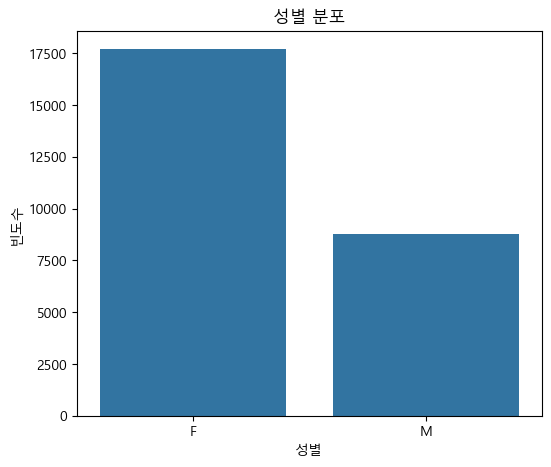

빈도수 확인:
 gender
F    17697
M     8760
Name: count, dtype: int64

비율 확인:
 gender
F    0.668897
M    0.331103
Name: proportion, dtype: float64


In [37]:
# 그래프 크기 설정
plt.figure(figsize=(6, 5))

# 성별 분포 시각화 (막대 그래프)
sns.countplot(data=train, x='gender')

plt.title('성별 분포')
plt.xlabel('성별')
plt.ylabel('빈도수')
plt.show()

# 상세 수치 및 비율 확인
print("빈도수 확인:\n", train['gender'].value_counts())
print("\n비율 확인:\n", train['gender'].value_counts(normalize=True))

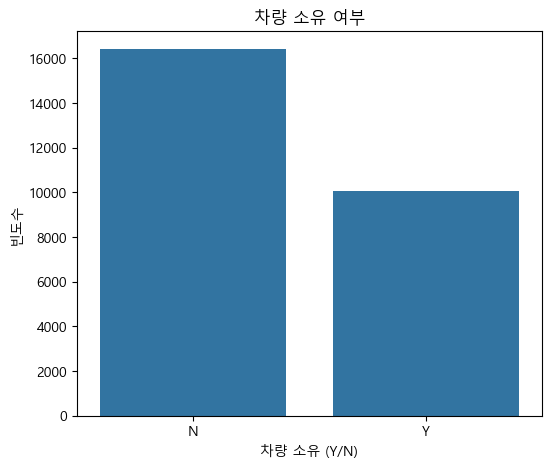

빈도수 확인:
 car
N    16410
Y    10047
Name: count, dtype: int64

비율 확인:
 car
N    0.620252
Y    0.379748
Name: proportion, dtype: float64


In [38]:
# 그래프 크기 설정
plt.figure(figsize=(6, 5))

# 차량 소유 여부 시각화
sns.countplot(data=train, x='car')

plt.title('차량 소유 여부')
plt.xlabel('차량 소유 (Y/N)')
plt.ylabel('빈도수')
plt.show()

# 상세 수치 및 비율 확인
print("빈도수 확인:\n", train['car'].value_counts())
print("\n비율 확인:\n", train['car'].value_counts(normalize=True))

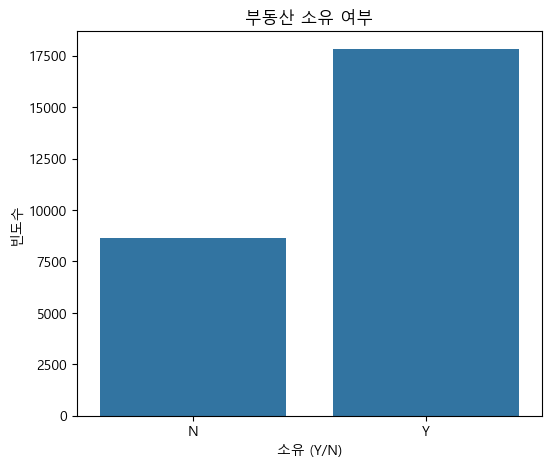

빈도수 확인:
 reality
Y    17830
N     8627
Name: count, dtype: int64

비율 확인:
 reality
Y    0.673924
N    0.326076
Name: proportion, dtype: float64


In [77]:
# 그래프 크기 설정
plt.figure(figsize=(6, 5))

# 부동산 소유 여부 시각화
sns.countplot(data=train, x='reality')

plt.title('부동산 소유 여부')
plt.xlabel('소유 (Y/N)')
plt.ylabel('빈도수')
plt.show()

# 상세 수치 및 비율 확인
print("빈도수 확인:\n", train['reality'].value_counts())
print("\n비율 확인:\n", train['reality'].value_counts(normalize=True))

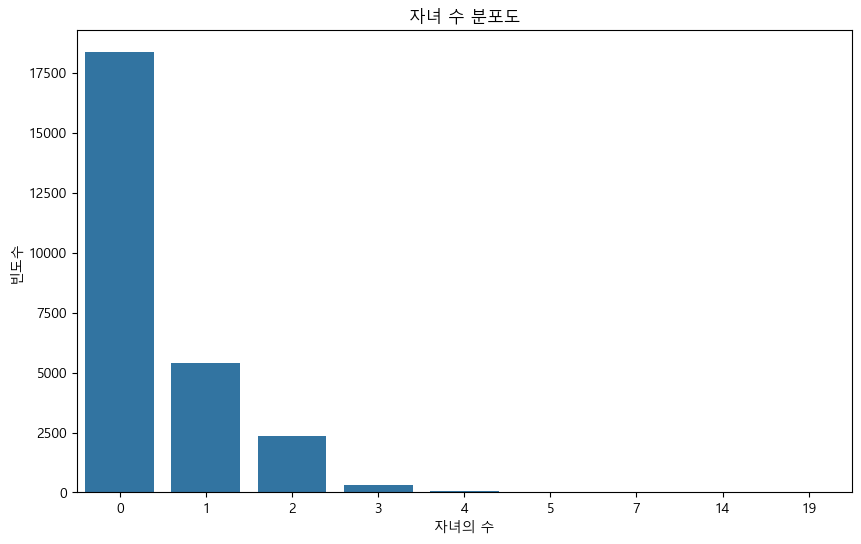

child_num
0     18340
1      5386
2      2362
3       306
4        47
5        10
7         2
14        3
19        1
Name: count, dtype: int64


In [41]:
plt.figure(figsize=(10, 6))

# 자녀 수별 빈도수 시각화
sns.countplot(data=train, x='child_num')

plt.title('자녀 수 분포도')
plt.xlabel('자녀의 수')
plt.ylabel('빈도수')
plt.show()

# 정확한 수치 확인
print(train['child_num'].value_counts().sort_index())

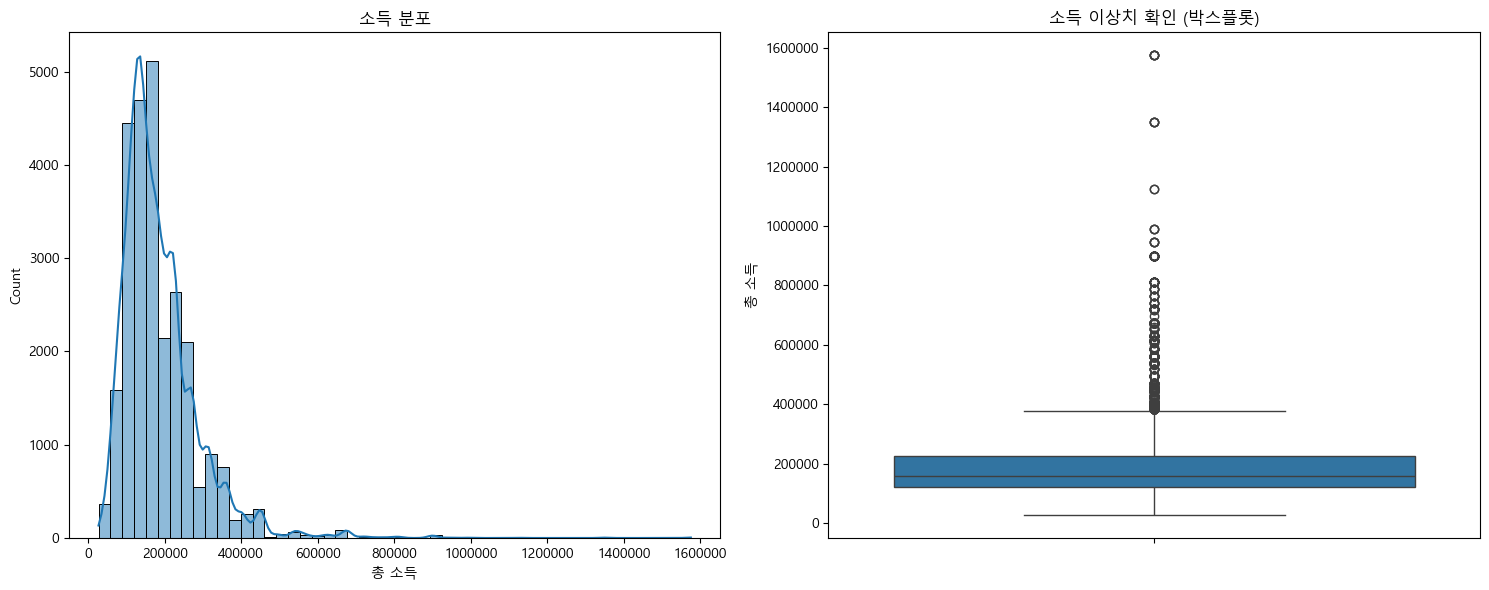

count    2.645700e+04
mean     1.873065e+05
std      1.018784e+05
min      2.700000e+04
25%      1.215000e+05
50%      1.575000e+05
75%      2.250000e+05
max      1.575000e+06
Name: income_total, dtype: float64


In [50]:
# 그래프 그리기 (2개 나란히 배치)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. 소득 분포 (히스토그램 + KDE 곡선)
sns.histplot(train['income_total'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('소득 분포')  # Income Distribution -> 소득 분포
axes[0].set_xlabel('총 소득')   # x축 라벨 추가
axes[0].ticklabel_format(style='plain', axis='x') # 과학적 표기법(e) 제거

# 2. 이상치 확인 (박스플롯)
sns.boxplot(y=train['income_total'], ax=axes[1])
axes[1].set_title('소득 이상치 확인 (박스플롯)')  # Income Boxplot -> 소득 이상치 확인
axes[1].set_ylabel('총 소득')   # y축 라벨 추가
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

# 상세 통계량 확인
print(train['income_total'].describe())

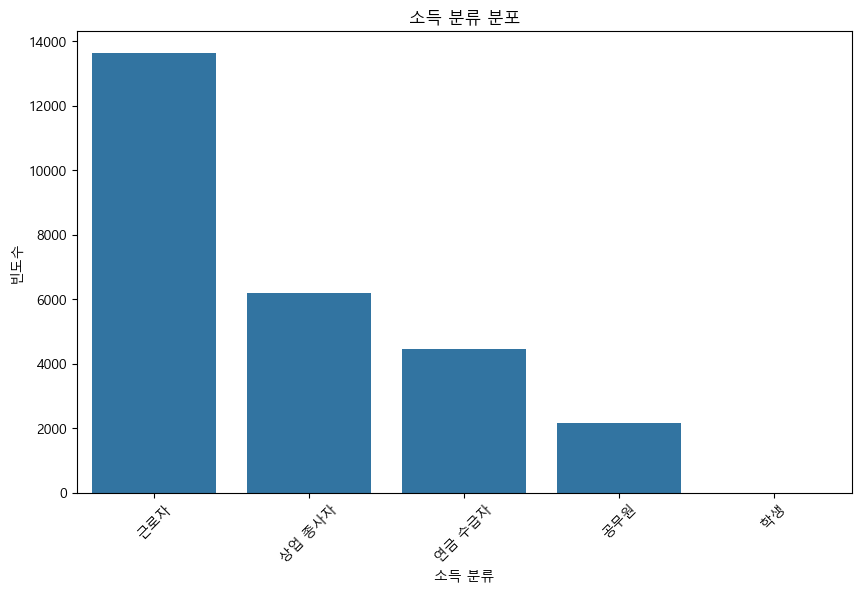

income_type
근로자       13645
상업 종사자     6202
연금 수급자     4449
공무원        2154
학생            7
Name: count, dtype: int64


In [79]:
# 그래프 크기 설정
plt.figure(figsize=(10, 6))

# 소득 분류별 빈도수 시각화 (빈도수 높은 순서로 정렬)
sns.countplot(data=train, 
              x='income_type', 
              order=train['income_type'].value_counts().index)

plt.title('소득 분류 분포')
plt.xlabel('소득 분류')
plt.ylabel('빈도수')
plt.xticks(rotation=45) # 텍스트가 겹치지 않게 45도 회전
plt.show()

# 상세 수치 출력
print(train['income_type'].value_counts())

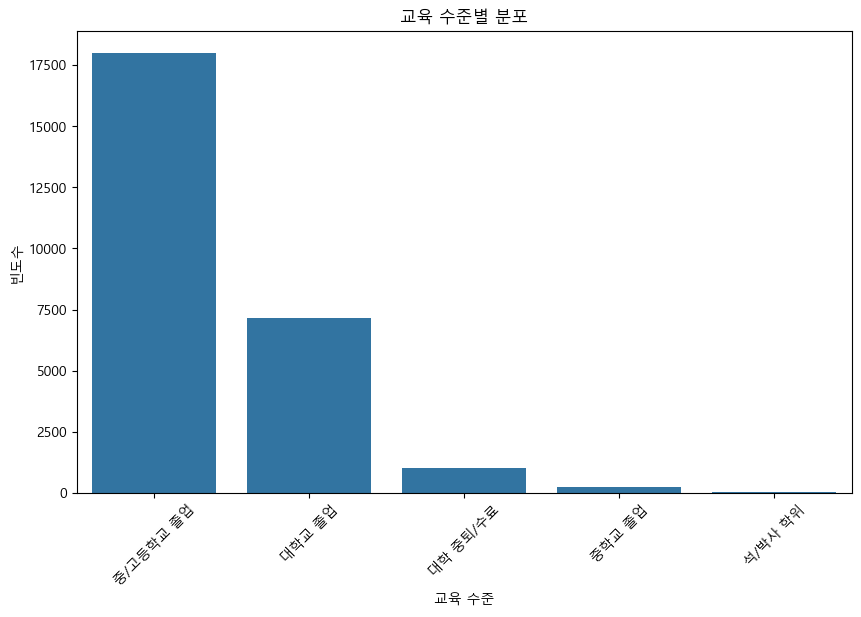

빈도수 확인:
 edu_type
중/고등학교 졸업    17995
대학교 졸업        7162
대학 중퇴/수료      1020
중학교 졸업         257
석/박사 학위         23
Name: count, dtype: int64

비율 확인:
 edu_type
중/고등학교 졸업    0.680160
대학교 졸업       0.270703
대학 중퇴/수료     0.038553
중학교 졸업       0.009714
석/박사 학위      0.000869
Name: proportion, dtype: float64


In [73]:
# 그래프 크기 설정
plt.figure(figsize=(10, 6))
# 교육 수준별 빈도수 시각화 (빈도수 순서대로 정렬)
sns.countplot(data=train, 
              x='edu_type', 
              order=train['edu_type'].value_counts().index)
plt.title('교육 수준별 분포')
plt.xlabel('교육 수준')
plt.ylabel('빈도수')
plt.xticks(rotation=45) # 이름이 길어서 45도 회전
plt.show()
# 상세 수치 및 비율 확인
print("빈도수 확인:\n", train['edu_type'].value_counts())
print("\n비율 확인:\n", train['edu_type'].value_counts(normalize=True))

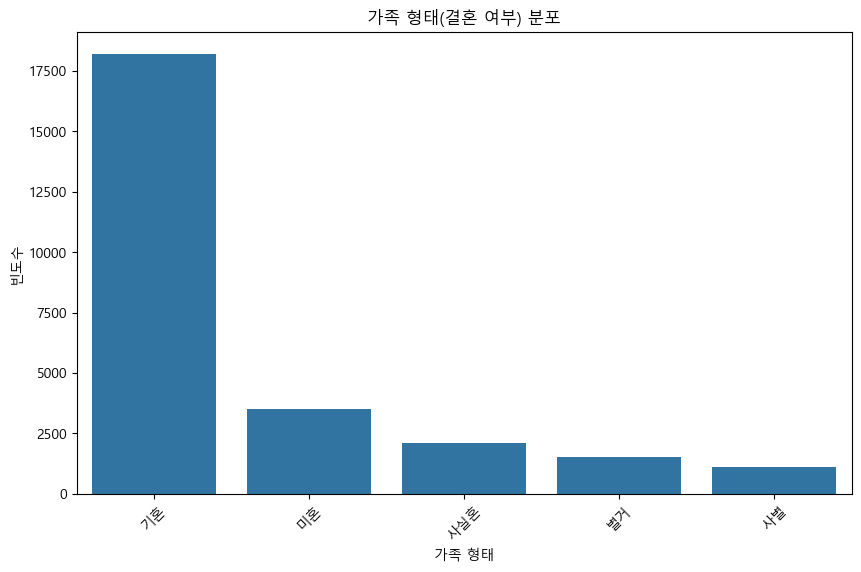

빈도수 확인:
 family_type
기혼     18196
미혼      3496
사실혼     2123
별거      1539
사별      1103
Name: count, dtype: int64

비율 확인:
 family_type
기혼     0.687757
미혼     0.132139
사실혼    0.080243
별거     0.058170
사별     0.041690
Name: proportion, dtype: float64


In [74]:
# 그래프 크기 설정
plt.figure(figsize=(10, 6))

# 가족 형태별 빈도수 시각화 (빈도수 순서대로 정렬)
sns.countplot(data=train, 
              x='family_type', 
              order=train['family_type'].value_counts().index)

plt.title('가족 형태(결혼 여부) 분포')
plt.xlabel('가족 형태')
plt.ylabel('빈도수')
plt.xticks(rotation=45) # 텍스트가 길 경우를 대비해 회전
plt.show()

# 상세 수치 및 비율 확인
print("빈도수 확인:\n", train['family_type'].value_counts())
print("\n비율 확인:\n", train['family_type'].value_counts(normalize=True))

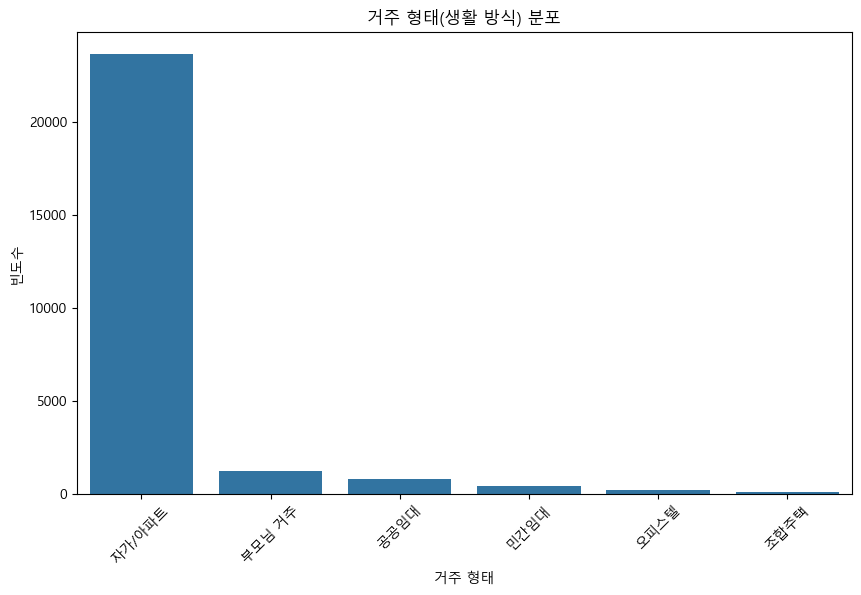

house_type
자가/아파트    23653
부모님 거주     1257
공공임대        818
민간임대        429
오피스텔        190
조합주택        110
Name: count, dtype: int64


In [76]:
# 그래프 크기 설정
plt.figure(figsize=(10, 6))

# 거주 형태별 빈도수 시각화 (빈도수 순서대로 정렬)
sns.countplot(data=train, 
              x='house_type', 
              order=train['house_type'].value_counts().index)

plt.title('거주 형태(생활 방식) 분포')
plt.xlabel('거주 형태')
plt.ylabel('빈도수')
plt.xticks(rotation=45) # 글자가 겹치지 않게 회전
plt.show()

# 상세 수치 확인
print(train['house_type'].value_counts())

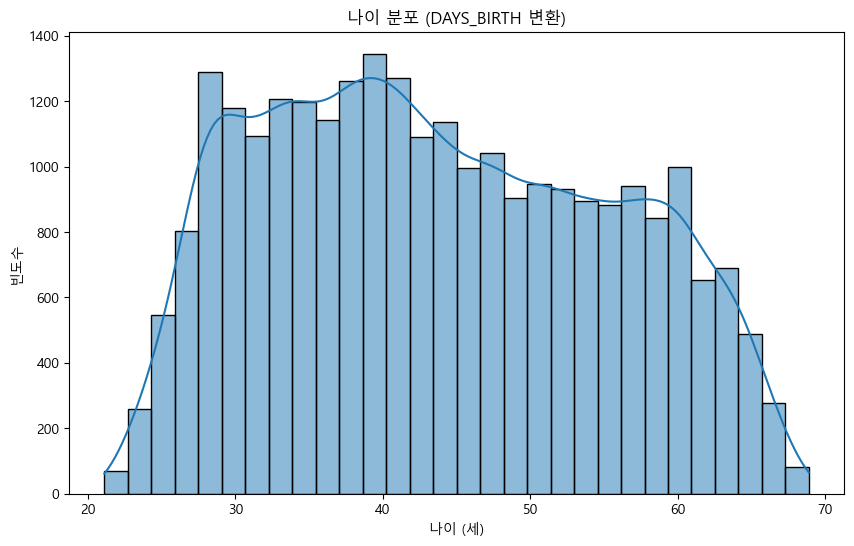

count    26457.000000
mean        43.720696
std         11.511203
min         21.109589
25%         34.098630
50%         42.594521
75%         53.235616
max         68.909589
Name: Age, dtype: float64


In [80]:
# 1. 보기 쉽게 '나이(만)'로 변환 
# (음수 값을 절대값(abs)으로 바꾸고 365로 나눔)
train['Age'] = abs(train['DAYS_BIRTH']) / 365
plt.figure(figsize=(10, 6))
# 2. 나이 분포 시각화 (히스토그램 + 곡선)
sns.histplot(train['Age'], bins=30, kde=True)
plt.title('나이 분포 (DAYS_BIRTH 변환)')
plt.xlabel('나이 (세)')
plt.ylabel('빈도수')
plt.show()
# 상세 통계량 확인 (최소, 최대 나이 등)
print(train['Age'].describe())

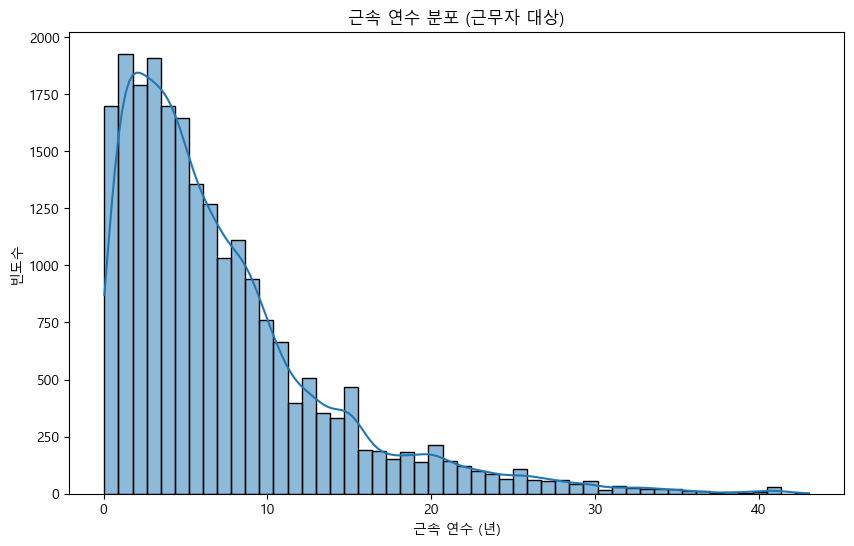

총 인원: 26457명
- 근무자 (음수): 22019명
- 무직/기타 (양수): 4438명

[근무자 근속 연수 통계]
count    22019.000000
mean         7.237398
std          6.471343
min          0.046575
25%          2.656164
50%          5.416438
75%          9.605479
max         43.049315
Name: DAYS_EMPLOYED, dtype: float64


In [81]:
# 시각화용 임시 데이터프레임
temp_train = train.copy()
# 1. 근무자(음수 값)만 필터링하여 '근속 연수' 계산
# 음수 값을 절대값(abs)으로 바꾸고 365로 나누어 '년' 단위로 변환
employed_mask = temp_train['DAYS_EMPLOYED'] < 0
years_employed = abs(temp_train.loc[employed_mask, 'DAYS_EMPLOYED']) / 365
plt.figure(figsize=(10, 6))
# 2. 근속 연수 분포 시각화 (근무자 대상)
sns.histplot(years_employed, bins=50, kde=True)
plt.title('근속 연수 분포 (근무자 대상)')
plt.xlabel('근속 연수 (년)')
plt.ylabel('빈도수')
plt.show()
# 3. 상세 정보 출력 (무직자 확인)
unemployed_count = (~employed_mask).sum() # 양수(0 포함)인 데이터 개수
print(f"총 인원: {len(temp_train)}명")
print(f"- 근무자 (음수): {len(years_employed)}명")
print(f"- 무직/기타 (양수): {unemployed_count}명")
print("\n[근무자 근속 연수 통계]")
print(years_employed.describe())

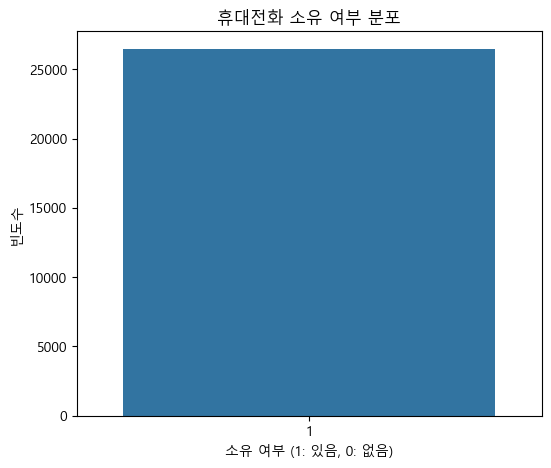

값별 개수:
 FLAG_MOBIL
1    26457
Name: count, dtype: int64


In [82]:
plt.figure(figsize=(6, 5))
# 휴대전화 소유 여부 시각화
sns.countplot(data=train, x='FLAG_MOBIL')
plt.title('휴대전화 소유 여부 분포')
plt.xlabel('소유 여부 (1: 있음, 0: 없음)')
plt.ylabel('빈도수')
plt.show()
# 정확한 수치 확인
print("값별 개수:\n", train['FLAG_MOBIL'].value_counts())

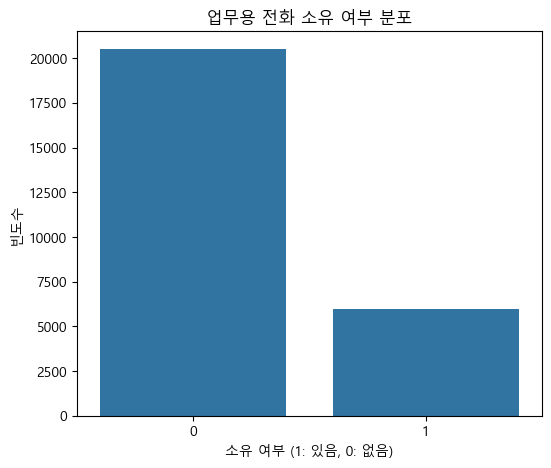

빈도수 확인:
 work_phone
0    20511
1     5946
Name: count, dtype: int64

비율 확인:
 work_phone
0    0.775258
1    0.224742
Name: proportion, dtype: float64


In [83]:
plt.figure(figsize=(6, 5))
# 업무용 전화 소유 여부 시각화
sns.countplot(data=train, x='work_phone')
plt.title('업무용 전화 소유 여부 분포')
plt.xlabel('소유 여부 (1: 있음, 0: 없음)')
plt.ylabel('빈도수')
plt.show()
# 정확한 수치 및 비율 확인
print("빈도수 확인:\n", train['work_phone'].value_counts())
print("\n비율 확인:\n", train['work_phone'].value_counts(normalize=True))

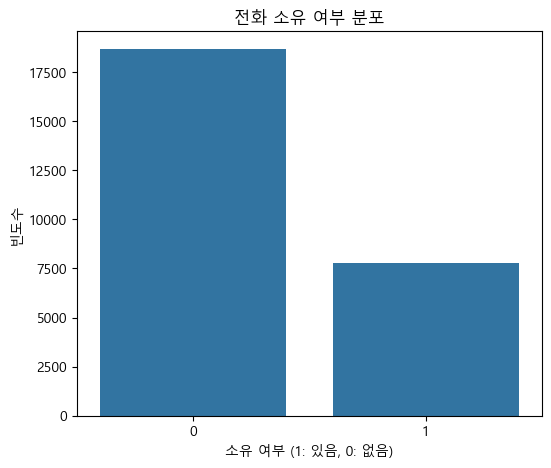

빈도수 확인:
 phone
0    18672
1     7785
Name: count, dtype: int64

비율 확인:
 phone
0    0.705749
1    0.294251
Name: proportion, dtype: float64


In [84]:
plt.figure(figsize=(6, 5))
# 가정용 전화 소유 여부 시각화
sns.countplot(data=train, x='phone')
plt.title('전화 소유 여부 분포')
plt.xlabel('소유 여부 (1: 있음, 0: 없음)')
plt.ylabel('빈도수')
plt.show()
# 정확한 수치 및 비율 확인
print("빈도수 확인:\n", train['phone'].value_counts())
print("\n비율 확인:\n", train['phone'].value_counts(normalize=True))

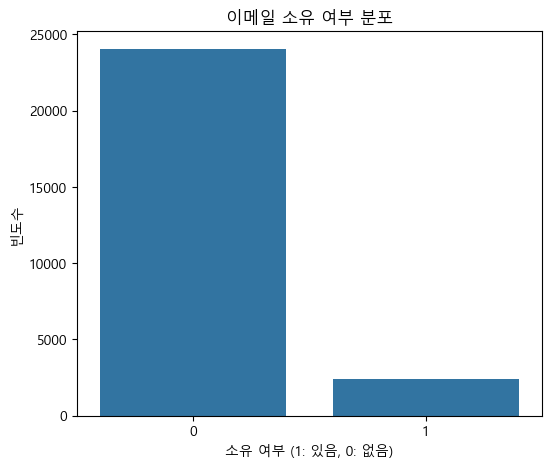

빈도수 확인:
 email
0    24042
1     2415
Name: count, dtype: int64

비율 확인:
 email
0    0.90872
1    0.09128
Name: proportion, dtype: float64


In [85]:
plt.figure(figsize=(6, 5))
# 이메일 소유 여부 시각화
sns.countplot(data=train, x='email')
plt.title('이메일 소유 여부 분포')
plt.xlabel('소유 여부 (1: 있음, 0: 없음)')
plt.ylabel('빈도수')
plt.show()
# 정확한 수치 및 비율 확인
print("빈도수 확인:\n", train['email'].value_counts())
print("\n비율 확인:\n", train['email'].value_counts(normalize=True))

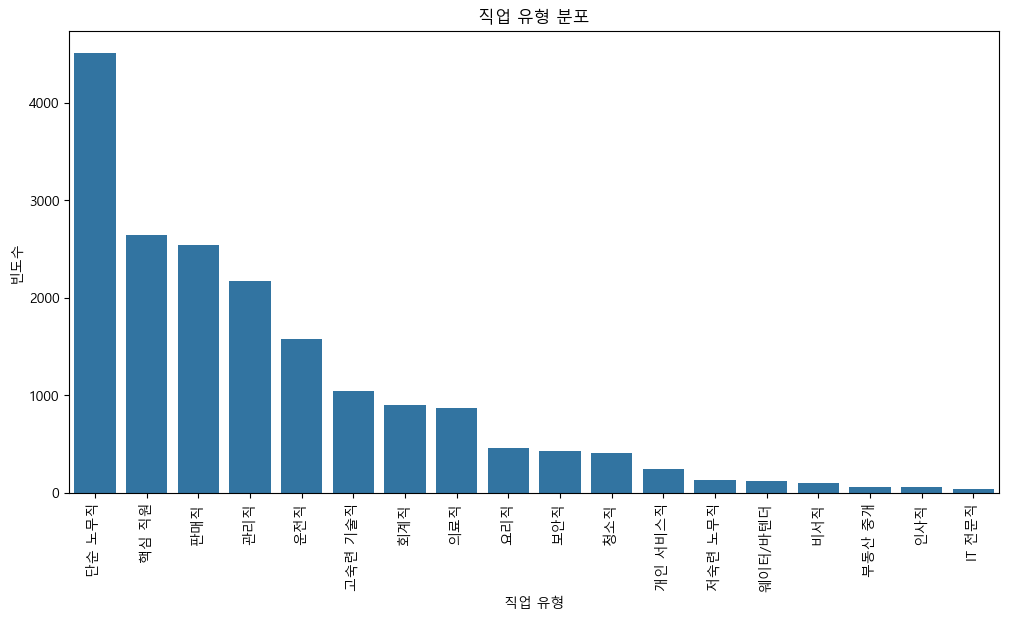

직업 정보 없음(결측치): 8171명

[상세 빈도수]
occyp_type
단순 노무직     4512
핵심 직원      2646
판매직        2539
관리직        2167
운전직        1575
고숙련 기술직    1040
회계직         902
의료직         864
요리직         457
보안직         424
청소직         403
개인 서비스직     243
저숙련 노무직     127
웨이터/바텐더     124
비서직          97
부동산 중개       63
인사직          62
IT 전문직       41
Name: count, dtype: int64


In [86]:
# 1. 직업 유형 한글 번역 딕셔너리 정의
occyp_type_dic = {
    'Laborers': '단순 노무직',
    'Core staff': '핵심 직원',
    'Sales staff': '판매직',
    'Managers': '관리직',
    'Drivers': '운전직',
    'High skill tech staff': '고숙련 기술직',
    'Accountants': '회계직',
    'Medicine staff': '의료직',
    'Cooking staff': '요리직',
    'Security staff': '보안직',
    'Cleaning staff': '청소직',
    'Private service staff': '개인 서비스직',
    'Low-skill Laborers': '저숙련 노무직',
    'Waiters/barmen staff': '웨이터/바텐더',
    'Secretaries': '비서직',
    'Realty agents': '부동산 중개',
    'HR staff': '인사직',
    'IT staff': 'IT 전문직'
}
# 2. 한글 매핑 적용 (결측치는 그대로 둠)
train['occyp_type'] = train['occyp_type'].map(occyp_type_dic)
test['occyp_type'] = test['occyp_type'].map(occyp_type_dic)
plt.figure(figsize=(12, 6))
# 3. 직업 유형별 빈도수 시각화 (빈도수 순서대로 정렬)
# 결측치(NaN)는 제외하고 그려집니다.
sns.countplot(data=train, 
              x='occyp_type', 
              order=train['occyp_type'].value_counts().index)
plt.title('직업 유형 분포')
plt.xlabel('직업 유형')
plt.ylabel('빈도수')
plt.xticks(rotation=90) # 항목이 많으므로 90도 회전
plt.show()
# 4. 결측치(직업 정보 없음) 개수 확인
print(f"직업 정보 없음(결측치): {train['occyp_type'].isnull().sum()}명")
print("\n[상세 빈도수]")
print(train['occyp_type'].value_counts())

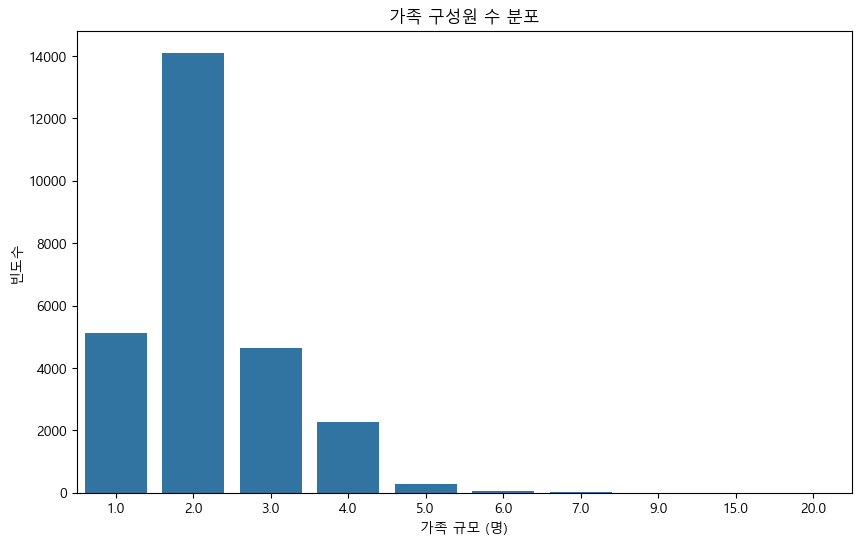

가족 규모별 빈도수 확인:
family_size
1.0      5109
2.0     14106
3.0      4632
4.0      2260
5.0       291
6.0        44
7.0         9
9.0         2
15.0        3
20.0        1
Name: count, dtype: int64


In [87]:
plt.figure(figsize=(10, 6))
# 가족 구성원 수 시각화
sns.countplot(data=train, x='family_size')
plt.title('가족 구성원 수 분포')
plt.xlabel('가족 규모 (명)')
plt.ylabel('빈도수')
plt.show()
# 상세 수치 확인 (인원 수별 통계)
print("가족 규모별 빈도수 확인:")
print(train['family_size'].value_counts().sort_index())

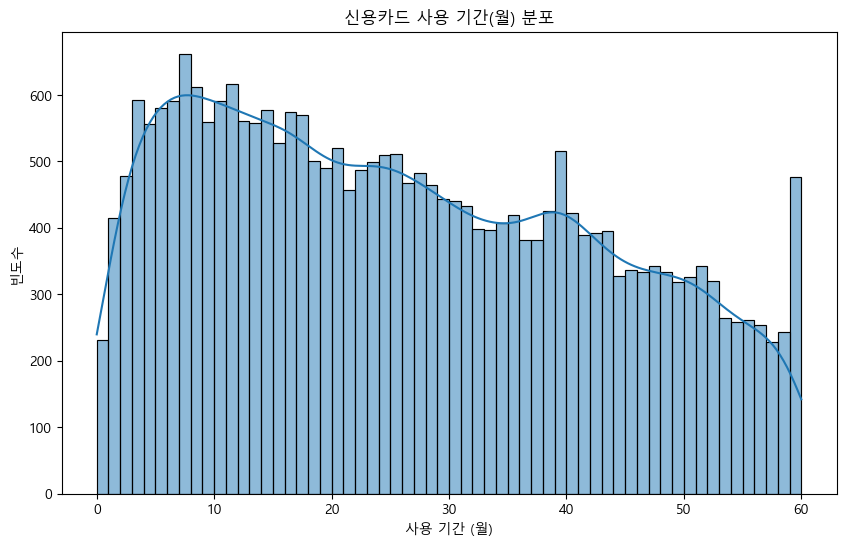

사용 기간 통계:
count    26457.000000
mean        26.123294
std         16.559550
min          0.000000
25%         12.000000
50%         24.000000
75%         39.000000
max         60.000000
Name: begin_month, dtype: float64


In [88]:
# 1. 보기 쉽게 '사용 기간'으로 변환 (음수 -> 양수)
# 숫자가 클수록 카드를 오래 사용했다는 뜻입니다.
card_duration = abs(train['begin_month'])
plt.figure(figsize=(10, 6))
# 2. 사용 기간 분포 시각화 (히스토그램)
sns.histplot(card_duration, bins=60, kde=True)
plt.title('신용카드 사용 기간(월) 분포')
plt.xlabel('사용 기간 (월)')
plt.ylabel('빈도수')
plt.show()
# 3. 상세 통계량 확인 (최대 사용 기간 등)
print("사용 기간 통계:")
print(card_duration.describe())

C:\Users\ailee\AppData\Local\Temp\ipykernel_15892\4258645835.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['0 (우량)', '1 (보통)', '2 (낮음/위험)'])


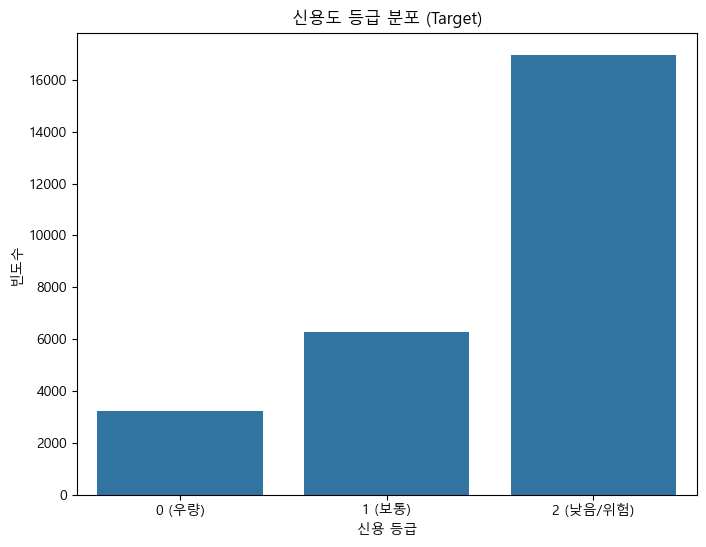

등급별 비율:
credit
0.0    0.121783
1.0    0.236875
2.0    0.641343
Name: proportion, dtype: float64


In [89]:
plt.figure(figsize=(8, 6))
# 신용도 등급 분포 시각화
ax = sns.countplot(data=train, x='credit')
plt.title('신용도 등급 분포 (Target)')
plt.xlabel('신용 등급')
plt.ylabel('빈도수')
# X축 라벨을 알기 쉽게 변경 (0: 우량, 1: 보통, 2: 낮음)
# 데이터셋 설명에 따르면 0이 가장 높은 신용도입니다.
ax.set_xticklabels(['0 (우량)', '1 (보통)', '2 (낮음/위험)'])
plt.show()
# 정확한 비율 확인
print("등급별 비율:")
print(train['credit'].value_counts(normalize=True).sort_index())